Import libraries

In [39]:
import pandas as pd
import numpy as np
import fastf1
from xgboost import XGBRegressor
from sklearn.impute import SimpleImputer
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patheffects as pe
warnings.filterwarnings("ignore")
fastf1.Cache.enable_cache('cache') 
fastf1.set_log_level('CRITICAL')

2026 AUS GP Qualifying data

In [27]:
session = fastf1.get_session(2026, 'Australia', 'Q')
session.load()

qualifying_df = session.results
qualifying_df = qualifying_df[['Position', 'DriverNumber', 'Abbreviation', 'TeamName', 'Q1', 'Q2', 'Q3']]

qualifying_df.loc[qualifying_df['DriverNumber'] == '18', 'Position'] = 20.0
qualifying_df.loc[qualifying_df['DriverNumber'] == '3', 'Position'] = 21.0
qualifying_df.loc[qualifying_df['DriverNumber'] == '55', 'Position'] = 22.0

qualifying_df['Q1'] = qualifying_df['Q1'].dt.total_seconds()
qualifying_df['Q2'] = qualifying_df['Q2'].dt.total_seconds()
qualifying_df['Q3'] = qualifying_df['Q3'].dt.total_seconds()

team_points_2025 = {
    "McLaren": 800, "Mercedes": 459, "Red Bull Racing": 426, "Williams": 137, "Ferrari": 382,
    "Haas F1 Team": 73, "Aston Martin": 80, "Audi": 68, "Racing Bulls": 92, "Alpine": 22, "Cadillac" : 5
}

max_points = max(team_points_2025.values())
team_performance_score = {team: (points / max_points) for team, points in team_points_2025.items()}

qualifying_df["OldTeamPerformance"] = qualifying_df["TeamName"].map(team_performance_score)

reg_change_boost = {
    "Mercedes" : 1.5, "Ferrari" : 1.3, "Red Bull Racing" : 0.80, "McLaren" : 0.90,
    "Williams" : 0.70, "Aston Martin" : 0.45, "Haas F1 Team" : 0.75, "Racing Bulls" : 0.80,
    "Audi" : 0.80, "Alpine" : 0.85, "Cadillac" : 0.50
}

qualifying_df["RegChangeBoost"] = qualifying_df["TeamName"].map(reg_change_boost)
qualifying_df["AdjustedTeamPerformanceScore"] = qualifying_df["RegChangeBoost"] * qualifying_df["OldTeamPerformance"]
qualifying_df = qualifying_df.drop(columns=["RegChangeBoost", "OldTeamPerformance"])

qualifying_df["QualiTime(s)"] = qualifying_df[["Q1", "Q2", "Q3"]].min(axis=1)
qualifying_df = qualifying_df.drop(columns=["Q1", "Q2", "Q3"])
qualifying_df["QualiTime(s)"] = qualifying_df["QualiTime(s)"].fillna(qualifying_df["QualiTime(s)"].max() + 1)

pole_position = qualifying_df["QualiTime(s)"].min()
qualifying_df["Quali_Delta_Pct"] = ((qualifying_df["QualiTime(s)"] - pole_position) / pole_position) * 100
qualifying_df["GridPenalty(s)"] = (qualifying_df["Position"] - 1) * 0.15

qualifying_df.head()

,Position,DriverNumber,Abbreviation,TeamName,AdjustedTeamPerformanceScore,QualiTime(s),Quali_Delta_Pct,GridPenalty(s)
63,1.0,63,RUS,Mercedes,0.860625,78.518,0.000000,0.00
12,2.0,12,ANT,Mercedes,0.860625,78.811,0.373163,0.15
6,3.0,6,HAD,Red Bull Racing,0.426000,79.303,0.999771,0.30
16,4.0,16,LEC,Ferrari,0.620750,79.327,1.030337,0.45
81,5.0,81,PIA,McLaren,0.900000,79.380,1.097837,0.60


2026 AUS GP FP2 data

In [28]:
fp2 = fastf1.get_session(2026, 'Australia', 'FP2')
fp2.load()
laps = fp2.laps

drivers = pd.unique(laps['Driver'])
pace_data = []

for driver in drivers:
    driver_laps = laps.pick_driver(driver).pick_quicklaps().dropna(subset=["LapTime"])
    
    if len(driver_laps) > 0:
        team = laps.pick_driver(driver)['Team'].iloc[0]
        
        if len(driver_laps) > 1:
            median_pace = driver_laps['LapTime'].median().total_seconds()
            # Tyre degradation with linear regression
            degradation = np.polyfit(range(len(driver_laps)), driver_laps['LapTime'].dt.total_seconds(), 1)[0]

        pace_data.append({
            'Driver' : driver,
            'Team' : team,
            'FP2_median_pace' : median_pace,
            'Tyre_Degradation' : degradation
        })

pace_data_df = pd.DataFrame(pace_data)

if not pace_data_df.empty:
    # For NaN data, replace with teammate's data
    pace_data_df['FP2_median_pace'] = pace_data_df.groupby('Team')['FP2_median_pace'].transform(lambda x: x.fillna(x.mean()))
    pace_data_df['Tyre_Degradation'] = pace_data_df.groupby('Team')['Tyre_Degradation'].transform(lambda x: x.fillna(x.mean()))
    
    best_fp2_pace = pace_data_df['FP2_median_pace'].min()
    pace_data_df['FP2_Delta_Pct'] = ((pace_data_df['FP2_median_pace'] - best_fp2_pace) / best_fp2_pace) * 100

pace_data_df.sample(5)

,Driver,Team,FP2_median_pace,Tyre_Degradation,FP2_Delta_Pct
8,LEC,Ferrari,81.8140,0.353500,0.470954
20,PIA,McLaren,83.9270,0.468191,3.065805
12,LAW,Racing Bulls,85.6040,0.325054,5.125229
1,VER,Red Bull Racing,82.2100,0.892400,0.957258
16,HAM,Ferrari,81.4305,0.391839,0.000000


Merging qualifying and FP2 data

In [29]:
merged = pd.merge(qualifying_df, pace_data_df, left_on="Abbreviation", right_on="Driver", how="left")
merged = merged.drop(columns=["Driver", "Team", "FP2_median_pace"]) 

Building the dataset with historic data from 2024, 2025

In [ ]:
def build_historical_dataset(years):
    historical_data = []
    # Team scores based on previous F1 championships
    team_scores_history = {
        "Red Bull Racing": 0.90, "McLaren": 0.95, "Ferrari": 0.80, "Mercedes": 0.75,
        "Aston Martin": 0.40, "Alpine": 0.40, "Williams": 0.50, "Racing Bulls": 0.45,
        "Haas F1 Team": 0.35, "Kick Sauber": 0.35 
    }
    
    for year in years:
        schedule = fastf1.get_event_schedule(year)
        # Focus on non-testing events
        races = schedule[schedule['EventFormat'] != 'testing']['EventName'].tolist()
        
        for race in races:
            try:
                # Qualifying
                quali = fastf1.get_session(year, race, 'Q')
                quali.load(telemetry=False, weather=False, messages=False)
                q_results = quali.results
                
                if 'Q3' not in q_results.columns or q_results['Q3'].isna().all():
                    continue
                pole_time = q_results['Q3'].min().total_seconds()
                
                # Race
                race_session = fastf1.get_session(year, race, 'R')
                race_session.load(telemetry=False, weather=False, messages=False)
                r_results = race_session.results
                
                # FP2
                fp2_deltas = {}
                fp2_degs = {}
                try:
                    fp2_hist = fastf1.get_session(year, race, 'FP2')
                    fp2_hist.load(telemetry=False, weather=False, messages=False)
                    fp2_laps = fp2_hist.laps
                    
                    hist_paces = []
                    for d in pd.unique(fp2_laps['Driver']):
                        dl = fp2_laps.pick_driver(d).pick_quicklaps().dropna(subset=["LapTime"])
                        if len(dl) > 1:
                            mp = dl['LapTime'].median().total_seconds()
                            deg = np.polyfit(range(len(dl)), dl['LapTime'].dt.total_seconds(), 1)[0]
                            hist_paces.append({'Driver': d, 'pace': mp, 'deg': deg})
                    
                    if hist_paces:
                        h_df = pd.DataFrame(hist_paces)
                        best_hist_pace = h_df['pace'].min()
                        for _, row in h_df.iterrows():
                            fp2_deltas[row['Driver']] = ((row['pace'] - best_hist_pace) / best_hist_pace) * 100
                            fp2_degs[row['Driver']] = row['deg']
                except:
                    pass # Ignore if FP2 is missing (Sprint weekends)

                # Building the dataset
                for _, driver in q_results.iterrows():
                    abb = driver['Abbreviation']
                    times = [driver.get('Q1'), driver.get('Q2'), driver.get('Q3')]
                    valid_times = [t.total_seconds() for t in times if pd.notnull(t)]
                    
                    if not valid_times or pd.isna(pole_time): continue
                    q_time = min(valid_times)
                    q_delta_pct = ((q_time - pole_time) / pole_time) * 100
                    
                    race_driver = r_results[r_results['Abbreviation'] == abb]
                    if race_driver.empty or race_driver['Status'].iloc[0] != 'Finished':
                        continue 

                    target_pos = race_driver['Position'].iloc[0]

                    # If Position is NaN (e.g DNF) we set it 22th
                    if pd.isna(target_pos):
                        target_pos = 22.0
                        
                    historical_data.append({
                        'Quali_Delta_Pct': q_delta_pct,
                        'GridPosition': race_driver['GridPosition'].iloc[0],
                        'TeamPerformanceScore': team_scores_history.get(driver['TeamName'], 0.5),
                        'FP2_Delta_Pct': fp2_deltas.get(abb, np.nan),
                        'Tyre_Degradation': fp2_degs.get(abb, np.nan),
                        'Target_Race_Position': race_driver['Position'].iloc[0]
                    })
            except Exception as e:
                print(f"Ignorato {year} {race}: dati incompleti. ({e})")
                
    return pd.DataFrame(historical_data)

df_train = build_historical_dataset([2024,2025])

X, y definitions and imputing missing data

In [31]:
# X, y definition
features = ['Quali_Delta_Pct', 'GridPosition', 'TeamPerformanceScore', 'FP2_Delta_Pct', 'Tyre_Degradation']

X_hist = df_train[features]
y_hist = df_train['Target_Race_Position']

# Using an imputer to ged rid of NaN data
imputer = SimpleImputer(strategy='median')
X_hist_imputed = pd.DataFrame(imputer.fit_transform(X_hist), columns=X_hist.columns)

Defining and fitting our XGBRegressor model

In [ ]:
model = XGBRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
model.fit(X_hist_imputed, y_hist)

Defining the Dataset for 2026 results and prediction with the XGBRegressor model

In [37]:
X_2026 = pd.DataFrame({
    'Quali_Delta_Pct': merged["Quali_Delta_Pct"],
    'GridPosition': merged["Position"], 
    'TeamPerformanceScore': merged["AdjustedTeamPerformanceScore"],
    'FP2_Delta_Pct': merged["FP2_Delta_Pct"],
    'Tyre_Degradation': merged["Tyre_Degradation"]
})

X_2026_imputed = pd.DataFrame(imputer.transform(X_2026), columns=X_2026.columns)

# Prediction on Race Position 
merged["Predicted_Race_Position_Raw"] = model.predict(X_2026_imputed)

final_predictions = merged.sort_values(by="Predicted_Race_Position_Raw", ascending=True).reset_index(drop=True)
final_predictions["Final_Predicted_Position"] = final_predictions.index + 1
print("\nPREDICTED 2026 F1 AUSTRALIAN GRAN PRIX RESULTS:")
final_predictions[['Final_Predicted_Position', 'Abbreviation', 'TeamName', 'Predicted_Race_Position_Raw']]


PREDICTED 2026 F1 AUSTRALIAN GRAN PRIX RESULTS:


,Final_Predicted_Position,Abbreviation,TeamName,Predicted_Race_Position_Raw
0,1,RUS,Mercedes,1.207037
1,2,ANT,Mercedes,2.213382
2,3,LEC,Ferrari,4.930851
3,4,PIA,McLaren,4.931106
4,5,HAD,Red Bull Racing,5.015162
5,6,NOR,McLaren,5.257892
6,7,VER,Red Bull Racing,6.180680
7,8,STR,Aston Martin,6.898308
8,9,BOT,Cadillac,8.166021
9,10,HAM,Ferrari,8.408565


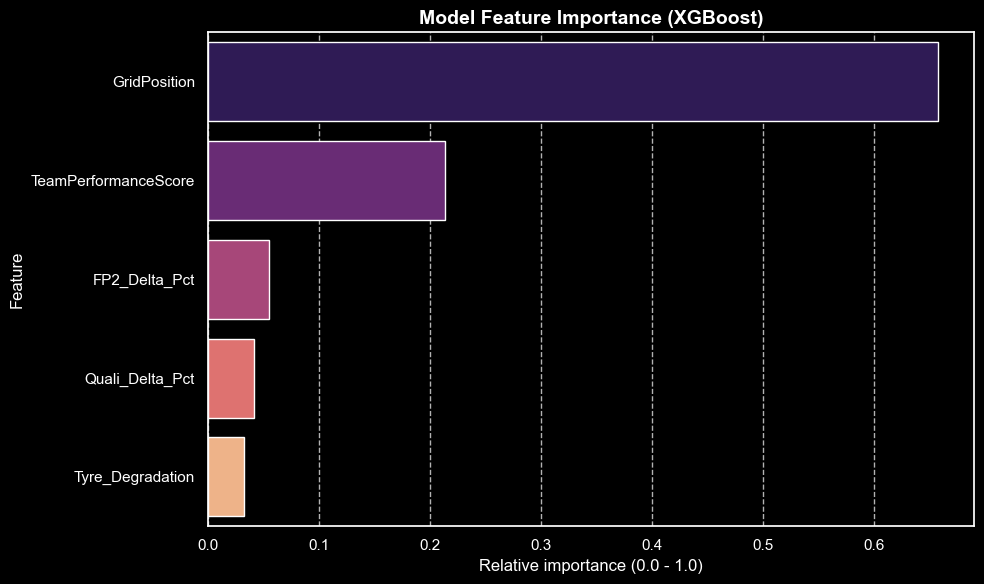

In [34]:
# Analyzing features importance
feature_importances = model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

importance_df['Importance_Pct'] = (importance_df['Importance'] * 100).round(2).astype(str) + '%'

# Plot histogram
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')

plt.title('Model Feature Importance (XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Relative importance (0.0 - 1.0)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

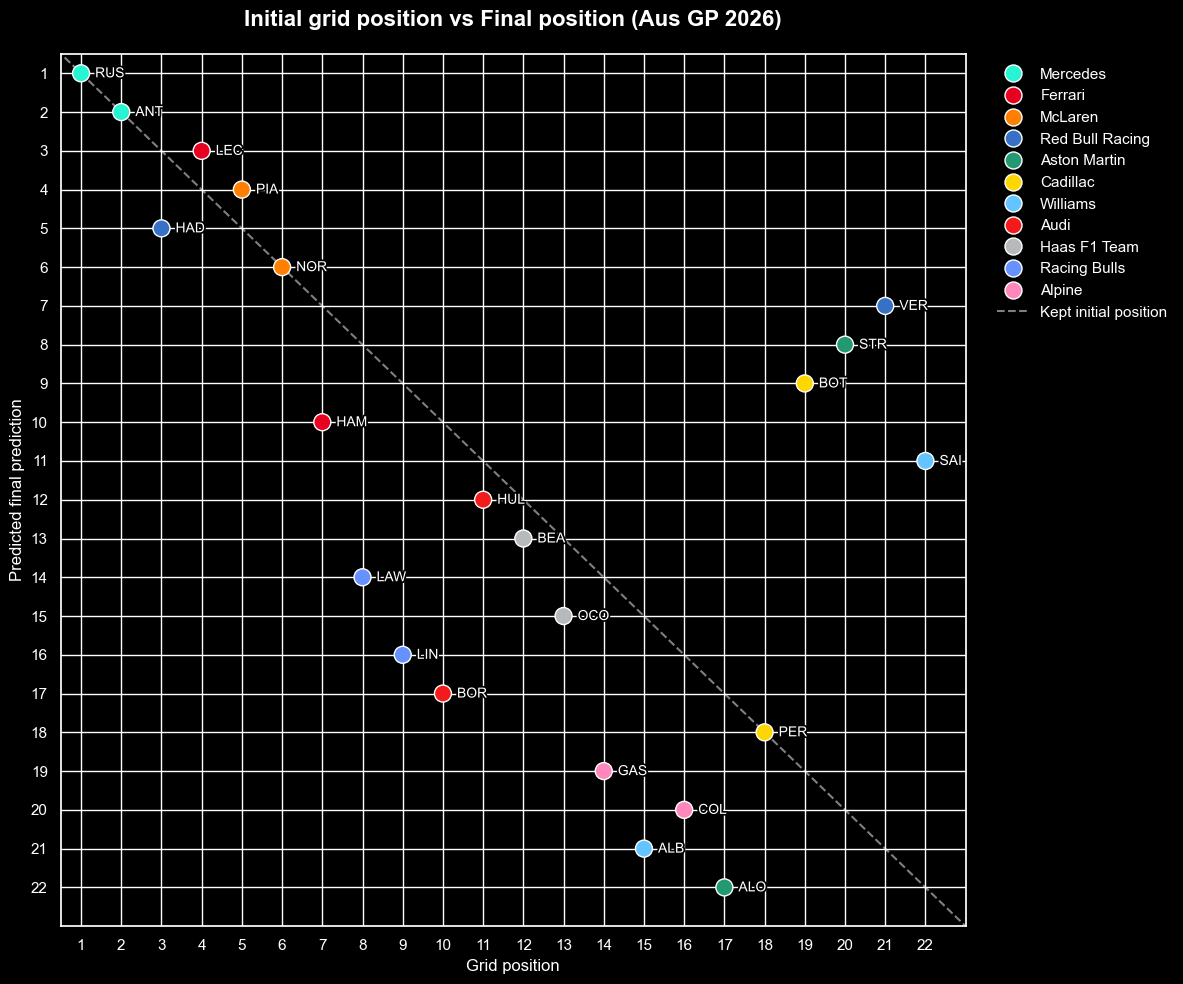

In [40]:
plt.style.use('dark_background')

team_colors = {
    "Mercedes": "#27F4D2",
    "Ferrari": "#E80020",
    "Red Bull Racing": "#3671C6",
    "McLaren": "#FF8000",
    "Williams": "#64C4FF",
    "Aston Martin": "#229971",
    "Haas F1 Team": "#B6BABD",
    "Racing Bulls": "#6692FF",
    "Audi": "#F21A1A",       
    "Alpine": "#FF87BC",     
    "Cadillac": "#FFD700"    
}

plt.figure(figsize=(12, 10))

sns.scatterplot(
    data=final_predictions, 
    x='Position', 
    y='Final_Predicted_Position', 
    hue='TeamName', 
    palette=team_colors, 
    s=150, 
    edgecolor='white', 
    linewidth=1,
    zorder=3 
)

plt.plot([0, 23], [0, 23], color='white', linestyle='--', alpha=0.5, label='Kept initial position', zorder=1)

for index, row in final_predictions.iterrows():
    plt.text(
        row['Position'] + 0.35, 
        row['Final_Predicted_Position'], 
        row['Abbreviation'], 
        size=10,
        color='white',
        va='center', 
        path_effects=[pe.withStroke(linewidth=2.5, foreground="black")], 
        zorder=4
    )

plt.title("Initial grid position vs Final position (Aus GP 2026)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Grid position", fontsize=12)
plt.ylabel("Predicted final prediction", fontsize=12)

plt.xticks(np.arange(1, 23, 1))
plt.yticks(np.arange(1, 23, 1))

plt.xlim(0.5, 23)
plt.ylim(23, 0.5) 

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.tight_layout()

plt.show()

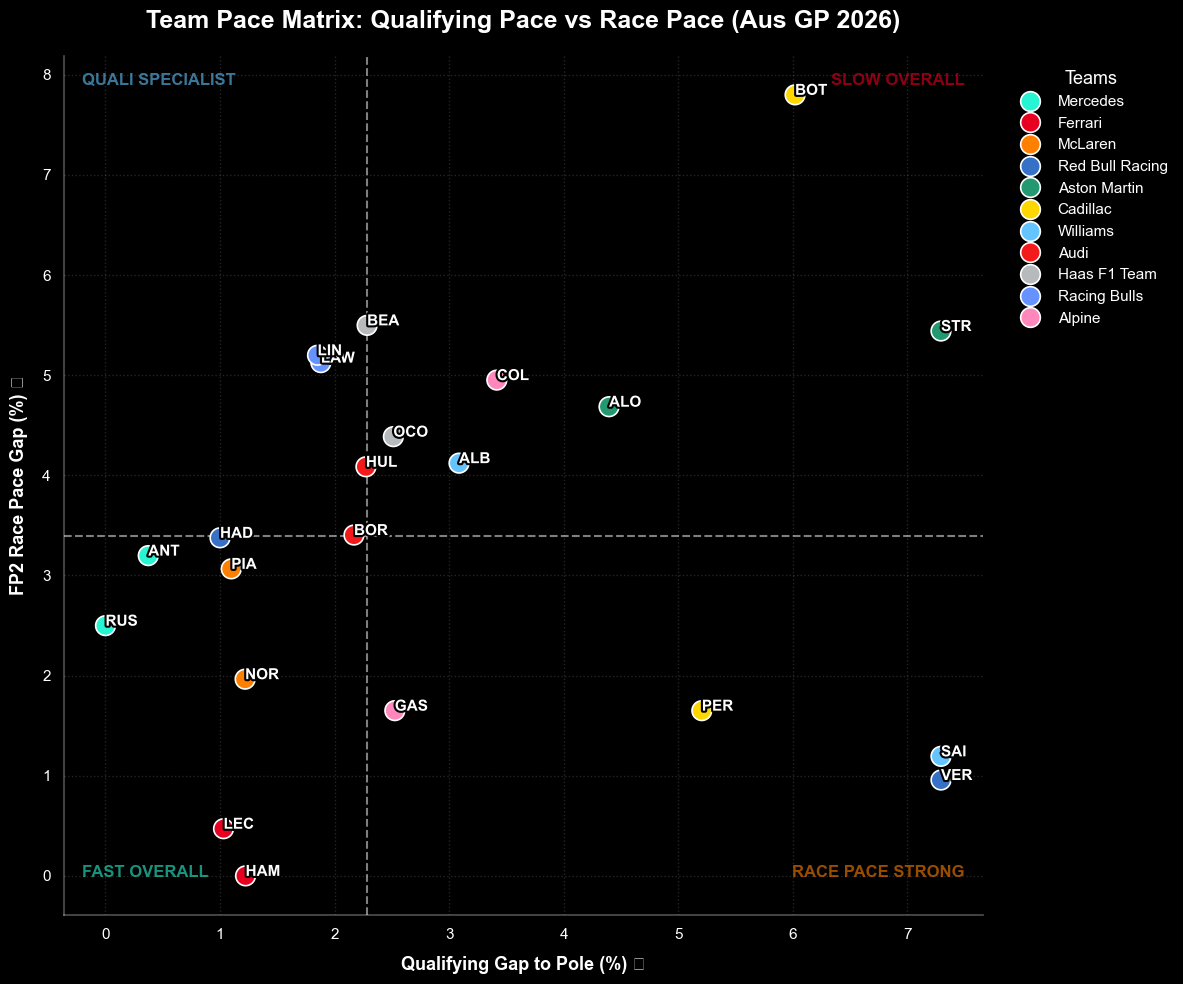

In [41]:
fig, ax = plt.subplots(figsize=(12, 10))

sns.scatterplot(
    data=final_predictions, 
    x='Quali_Delta_Pct', 
    y='FP2_Delta_Pct', 
    hue='TeamName', 
    palette=team_colors, 
    s=200, 
    edgecolor='white', 
    linewidth=1.2,
    zorder=3,
    ax=ax
)

median_quali = final_predictions['Quali_Delta_Pct'].median()
median_fp2 = final_predictions['FP2_Delta_Pct'].median()

ax.axvline(median_quali, color='white', linestyle='--', alpha=0.5, zorder=2)
ax.axhline(median_fp2, color='white', linestyle='--', alpha=0.5, zorder=2)

ax.grid(color='white', linestyle=':', alpha=0.15, zorder=1)

texts = []
for index, row in final_predictions.iterrows():
    texts.append(
        ax.text(
            row['Quali_Delta_Pct'], 
            row['FP2_Delta_Pct'], 
            row['Abbreviation'], 
            size=11,
            color='white',
            fontweight='bold',
            path_effects=[pe.withStroke(linewidth=3, foreground="black")],
            zorder=4
        )
    )


text_kwargs = dict(fontsize=12, fontweight='bold', alpha=0.6, transform=ax.transAxes)

ax.text(0.02, 0.02, 'FAST OVERALL\n', color='#27F4D2', ha='left', va='bottom', **text_kwargs)
ax.text(0.02, 0.98, 'QUALI SPECIALIST\n', color='#64C4FF', ha='left', va='top', **text_kwargs)
ax.text(0.98, 0.02, 'RACE PACE STRONG\n', color='#FF8000', ha='right', va='bottom', **text_kwargs)
ax.text(0.98, 0.98, 'SLOW OVERALL\n', color='#E80020', ha='right', va='top', **text_kwargs)

ax.set_title("Team Pace Matrix: Qualifying Pace vs Race Pace (Aus GP 2026)", fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel("Qualifying Gap to Pole (%) ➜", fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel("FP2 Race Pace Gap (%) ➜", fontsize=13, fontweight='bold', labelpad=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_alpha(0.3)
ax.spines['bottom'].set_alpha(0.3)

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, title="Teams", title_fontsize=13, fontsize=11)

plt.tight_layout()
plt.show()